In [ ]:
#Lectura del archivo, head, tail,sample, describe. Validación de columnas numéricas para que funcione con todas
# 1)Total de videojuegos analizados
# 2)Total de generos analizados
# 3)Plataformas analizadas
#Ventas:
#1) Total de ventas por año,
#2) Juegos más vendidos por año,
#3) Plataformas con más ingresos por año. 
#Todos estos números desglosados por ingreso:
#NA, EU, JP, Otros y el Global,
#4) Gráfico de comparación de ventas entre géneros por año, 
#Insights: 2 Gráficos adicionales interesantes

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df=pd.read_csv('vgsales.csv')

In [3]:
df.head(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
df.tail(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [5]:
df.sample(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
2728,2730,Total War: Rome II,PC,2013.0,Strategy,Sega,0.12,0.53,0.00,0.11,0.76
15589,15592,Peggle Nights,PC,2008.0,Puzzle,PopCap Games,0.00,0.01,0.00,0.00,0.02
9360,9362,Shovel Knight,3DS,2015.0,Platform,Yacht Club Games,0.07,0.04,0.01,0.01,0.13
5184,5186,LocoRoco 2,PSP,2008.0,Platform,Sony Computer Entertainment,0.21,0.09,0.01,0.05,0.36
13066,13068,Thunder Force V: Perfect System,PS,1998.0,Shooter,TechnoSoft,0.03,0.02,0.00,0.00,0.05


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [15]:
df = df.dropna(subset=['Year'])  
df['Year'] = df['Year'].astype(int)
df['Publisher'] = df['Publisher'].fillna('Unknown')

In [16]:
pd.options.display.float_format='{:.2f}'.format
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16327.00,16327.00,16327.00,16327.00,16327.00,16327.00,16327.00
mean,8292.87,2006.41,0.27,0.15,0.08,0.05,0.54
std,4792.67,5.83,0.82,0.51,0.31,0.19,1.57
min,1.00,1980.00,0.00,0.00,0.00,0.00,0.01
25%,4136.50,2003.00,0.00,0.00,0.00,0.00,0.06
50%,8295.00,2007.00,0.08,0.02,0.00,0.01,0.17
75%,12441.50,2010.00,0.24,0.11,0.04,0.04,0.48
max,16600.00,2020.00,41.49,29.02,10.22,10.57,82.74


In [17]:
df.shape[0]

16327

In [18]:
df.nunique()

Rank            16327
Name            11360
Platform           31
Year               39
Genre              12
Publisher         576
NA_Sales          408
EU_Sales          305
JP_Sales          244
Other_Sales       157
Global_Sales      621
dtype: int64

In [19]:
count_unique_names = df['Name'].nunique()
print(f'TOTAL DE {count_unique_names} VIDEOJUEGOS ANALIZADOS')

TOTAL DE 11360 VIDEOJUEGOS ANALIZADOS


In [20]:
count_unique_names = df['Genre'].nunique()
print(f'TOTAL DE {count_unique_names} GENEROS ANALIZADOS')

TOTAL DE 12 GENEROS ANALIZADOS


In [21]:
count_unique_names = df['Platform'].nunique()
print(f'TOTAL DE {count_unique_names} PLATAFORMAS ANALIZADAS')

TOTAL DE 31 PLATAFORMAS ANALIZADAS


In [50]:
df.groupby('Year')[['Global_Sales','NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum().sort_values(by='Global_Sales', ascending=False)

,Global_Sales,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Year,,,,,
2008.0,678.90,351.44,184.40,60.26,82.39
2009.0,667.30,338.85,191.59,61.89,74.77
2007.0,611.13,312.05,160.50,60.29,77.60
2010.0,600.45,304.24,176.73,59.49,59.90
2006.0,521.04,263.12,129.24,73.73,54.43
2011.0,515.99,241.06,167.44,53.04,54.39
2005.0,459.94,242.61,121.94,54.28,40.58
2004.0,419.31,222.59,107.32,41.65,47.29
2002.0,395.52,216.19,109.74,41.76,27.28


In [6]:
df.groupby("Year")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]].sum()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Year,,,,,
1980.0,10.59,0.67,0.00,0.12,11.38
1981.0,33.40,1.96,0.00,0.32,35.77
1982.0,26.92,1.65,0.00,0.31,28.86
1983.0,7.76,0.80,8.10,0.14,16.79
1984.0,33.28,2.10,14.27,0.70,50.36
1985.0,33.73,4.74,14.56,0.92,53.94
1986.0,12.50,2.84,19.81,1.93,37.07
1987.0,8.46,1.41,11.63,0.20,21.74
1988.0,23.87,6.59,15.76,0.99,47.22


In [9]:
df.loc[df.groupby("Year")["Global_Sales"].idxmax()][["Year","Name","Global_Sales"]].sort_values("Global_Sales", ascending=False)

,Year,Name,Global_Sales
0,2006.0,Wii Sports,82.74
1,1985.0,Super Mario Bros.,40.24
2,2008.0,Mario Kart Wii,35.82
3,2009.0,Wii Sports Resort,33.00
4,1996.0,Pokemon Red/Pokemon Blue,31.37
5,1989.0,Tetris,30.26
9,1984.0,Duck Hunt,28.31
10,2005.0,Nintendogs,24.76
12,1999.0,Pokemon Gold/Pokemon Silver,23.10
13,2007.0,Wii Fit,22.72


In [41]:
df.groupby('Name')[['Global_Sales','NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum().sort_values(by='Global_Sales', ascending=False).head(50)

,Global_Sales,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Name,,,,,
Wii Sports,82.74,41.49,29.02,3.77,8.46
Grand Theft Auto V,55.92,23.46,23.04,1.39,8.03
Super Mario Bros.,45.31,32.48,4.88,6.96,0.99
Tetris,35.84,26.17,2.95,6.03,0.69
Mario Kart Wii,35.82,15.85,12.88,3.79,3.31
Wii Sports Resort,33.00,15.75,11.01,3.28,2.96
Pokemon Red/Pokemon Blue,31.37,11.27,8.89,10.22,1.00
Call of Duty: Modern Warfare 3,30.83,15.58,11.29,0.62,3.35
New Super Mario Bros.,30.01,11.38,9.23,6.50,2.90


In [43]:
df.groupby('Platform')[['Global_Sales','NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum().sort_values(by='Global_Sales', ascending=False)

,Global_Sales,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Platform,,,,,
PS2,1233.46,572.92,332.63,137.54,190.47
X360,969.61,594.33,278.01,12.30,84.67
PS3,949.35,388.90,340.47,79.21,140.81
Wii,909.81,497.37,264.35,68.28,79.20
DS,818.96,388.56,194.07,175.02,60.29
PS,727.39,334.71,212.38,139.78,40.69
GBA,313.56,184.12,74.59,46.56,7.61
PSP,291.71,107.09,67.16,75.89,41.52
PS4,278.10,96.80,123.70,14.30,43.36


In [14]:
df.groupby(["Year", "Platform"])["Global_Sales"].sum().reset_index().sort_values(["Year", "Global_Sales"], ascending=[True, False]).groupby("Year").head(1)

,Year,Platform,Global_Sales
0,1980.0,2600,11.38
1,1981.0,2600,35.77
2,1982.0,2600,28.86
4,1983.0,NES,10.96
6,1984.0,NES,50.09
9,1985.0,NES,53.44
12,1986.0,NES,36.41
14,1987.0,NES,19.76
17,1988.0,NES,45.01
20,1989.0,GB,64.98


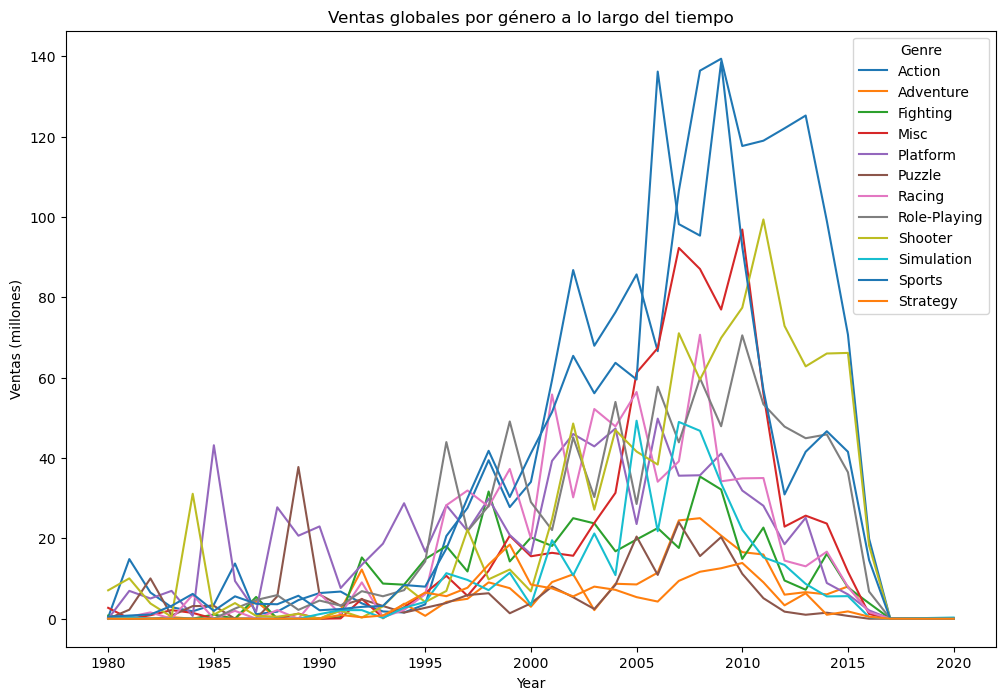

In [34]:
#Gráfico de comparación de ventas entre géneros por año, 
pivot_genre_year = df.pivot_table(values='Global_Sales', index='Year', columns='Genre', aggfunc='sum').fillna(0)
pivot_genre_year.plot(figsize=(12,8))
plt.title('Ventas globales por género a lo largo del tiempo')
plt.ylabel('Ventas (millones)')
plt.show()

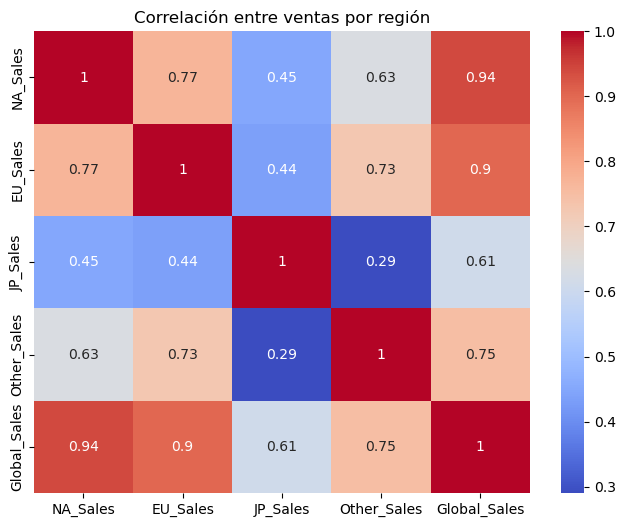

In [5]:
#Correlación de ventas regionales
corr = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlación entre ventas por región')
plt.show()

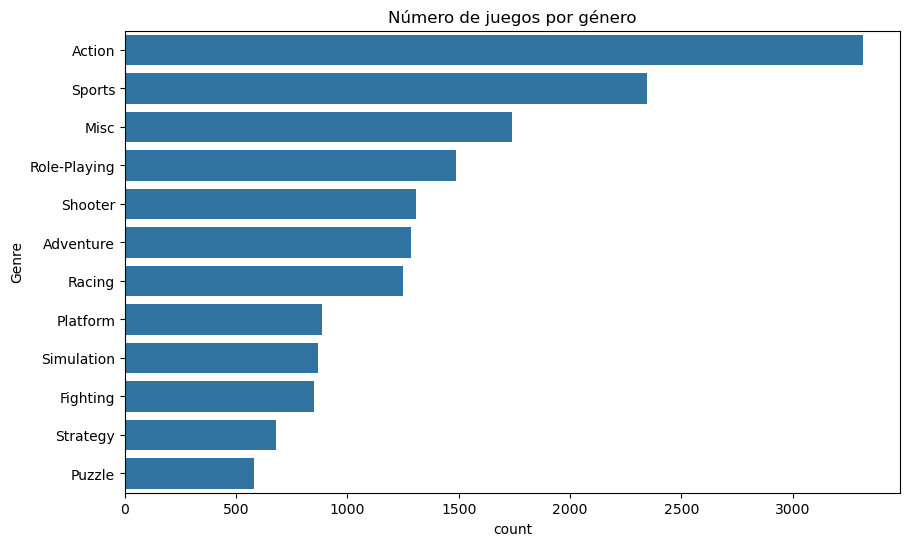

In [9]:
#Distribucion por generos
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Genre', order=df['Genre'].value_counts().index)
plt.title('Número de juegos por género')
plt.show()

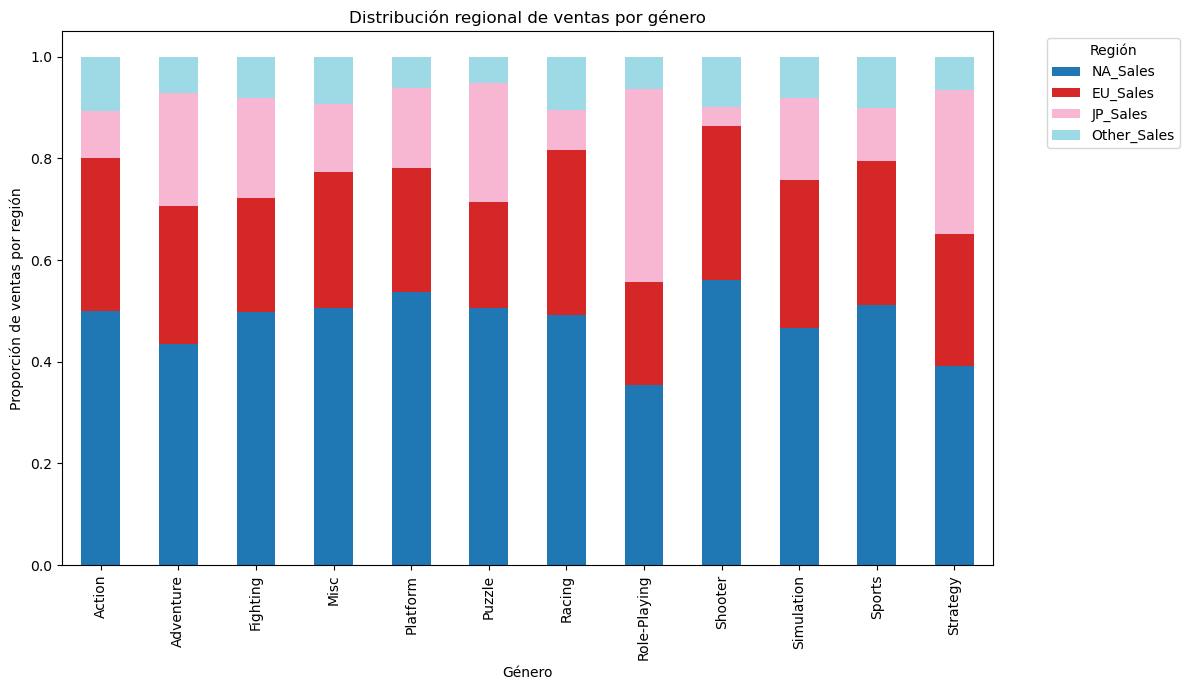

In [35]:
genre_region = df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
genre_region_norm = genre_region.div(genre_region.sum(axis=1), axis=0) 
genre_region_norm.plot(kind='bar', stacked=True, figsize=(12,7), colormap='tab20')
plt.title('Distribución regional de ventas por género')
plt.xlabel('Género')
plt.ylabel('Proporción de ventas por región')
plt.legend(title='Región', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
ventas_plat = df.groupby(["Year", "Platform"])["Global_Sales"].sum().reset_index()
crec_plataforma = (
    ventas_plat
    .pivot(index="Year", columns="Platform", values="Global_Sales")
    .pct_change(fill_method=None)
    .mean()
    .sort_values(ascending=False)
)
crec_plataforma

Platform
GBA     146.368479
GB        5.211909
GEN       3.278637
3DO       3.000000
XB        2.537660
PS        0.518696
NG        0.508351
XOne      0.377701
PS4       0.374337
X360      0.369563
DS        0.313013
2600      0.281907
NES       0.262223
PSP       0.181468
PC        0.117045
PS3       0.111813
PSV       0.068479
SAT       0.062715
DC        0.026668
PS2       0.015378
WS       -0.054987
SNES     -0.152992
GC       -0.181226
WiiU     -0.204144
N64      -0.285183
3DS      -0.289456
Wii      -0.316106
SCD      -0.753333
GG             NaN
PCFX           NaN
TG16           NaN
dtype: float64